# **SATELLITE-BASED LAND COVER FEATURE EXTRACTION AND CLASSIFICATION**

## **BUSINESS CASE** 
* Accurate land cover classification helps stakeholders understand land usage patterns, assess environmental changes, and make informed decisions in areas like agriculture, urban development, and disaster management.
* This classification can support environmental monitoring, urban planning, and resource management.

## **GOAL OF THE PROJECT**
* The project aims to extract the features from images and classify different types of land cover (e.g., urban, agriculture, forest, water) from satellite images.

## **TASK:** Multiclass Classification

![image.png](https://production-media.paperswithcode.com/datasets/EUROSAT.jpg)

## **DATA SUMMARY**

**Dataset Name**: EuroSAT Land Cover Classification Dataset  
**Data Source**: [Zenodo EuroSAT Dataset](https://zenodo.org/records/7711810)  
**Data Type**: Satellite Imagery  
**Data Format**:  
- RGB Images: .jpg (for 10 land cover classes)  
- Multispectral Images: .tif (for the same 10 land cover classes)  

**Number of Classes**: 10  
 
1. AnnualCrop  
2. Forest  
3. HerbaceousVegetation  
4. Highway  
5. Industrial  
6. Pasture  
7. PermanentCrop  
8. Residential  
9. River  
10. SeaLake  

**Total Number of Samples**: Approximately 27,000 images (3,000 images per class)  


## **DEVICE PROJECT INTO MULTIPLE STEPS**
* Prepare training, validation and testing set and perfrom Data Augmentation
* Get all classes labels
* Visualise the training images
* Create DCNN and use VGG19 model
* Model Compilation
* Model Training
* Model Evaluation
* Model Saving
* Prediction on test data

## **PYTHON IMPLIMENTATION**

In [1]:
#Import Necessary Liabrary
import numpy as np
import cv2
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Lambda, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# To supress warnings
import warnings
warnings.filterwarnings('ignore')


In [5]:
!pip install split-folders

In [6]:
import splitfolders

folder_path = "/kaggle/input/eurosat/EuroSAT_RGB"
splitfolders.ratio(folder_path, output="output",seed=1337, ratio=(.8, .1, .1)) 

Copying files: 27000 files [04:19, 103.95 files/s]


In [7]:
train_dir = "/kaggle/working/output/train"
val_dir = "/kaggle/working/output/val"
test_dir = "/kaggle/working/output/test"

In [8]:
train_datagen = ImageDataGenerator(rescale=(1.0/255),
                                   rotation_range=20,
                                   featurewise_center=True,
                                   featurewise_std_normalization=True,
                                   fill_mode='nearest',
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=(1./255))

test_datagen = ImageDataGenerator(rescale=(1./255))


In [9]:
train_set = train_datagen.flow_from_directory(train_dir,
                                              target_size=(64,64),
                                              batch_size=32,
                                              color_mode='rgb',
                                              class_mode='categorical')

val_set = val_datagen.flow_from_directory(val_dir,
                                          target_size=(64,64),
                                          batch_size=32,
                                          color_mode='rgb',
                                          class_mode='categorical')

test_set = test_datagen.flow_from_directory(test_dir,
                                            target_size=(64,64),
                                            batch_size=32,
                                            color_mode='rgb',
                                            class_mode='categorical')

Found 21600 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.


In [8]:
# Get classes indices
train_set.class_indices

{'AnnualCrop': 0,
 'Forest': 1,
 'HerbaceousVegetation': 2,
 'Highway': 3,
 'Industrial': 4,
 'Pasture': 5,
 'PermanentCrop': 6,
 'Residential': 7,
 'River': 8,
 'SeaLake': 9}

### **SEPRATE LABEL FROM TEST SET**

In [9]:
X_test, y_test = next(test_set)

In [10]:
print(X_test.shape)

(32, 64, 64, 3)


In [11]:
print(y_test)

[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0.

## **GET CLASS WEIGHTS**

In [12]:
# Get the class labels and their frequencies
from sklearn.utils.class_weight import compute_class_weight

class_labels = train_set.classes
unique_classes = np.unique(class_labels)

In [13]:
print("Class Labels: ", class_labels)
print("Unique Classes:", unique_classes)

Class Labels:  [0 0 0 ... 9 9 9]
Unique Classes: [0 1 2 3 4 5 6 7 8 9]


In [14]:
# Compute the class weights
class_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=class_labels)

# Create dict of class weights
class_weight_dict = dict(zip(unique_classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.9, 1: 0.9, 2: 0.9, 3: 1.08, 4: 1.08, 5: 1.35, 6: 1.08, 7: 0.9, 8: 1.08, 9: 0.9}


## **VISUALISE THE TRAINING IMAGES**

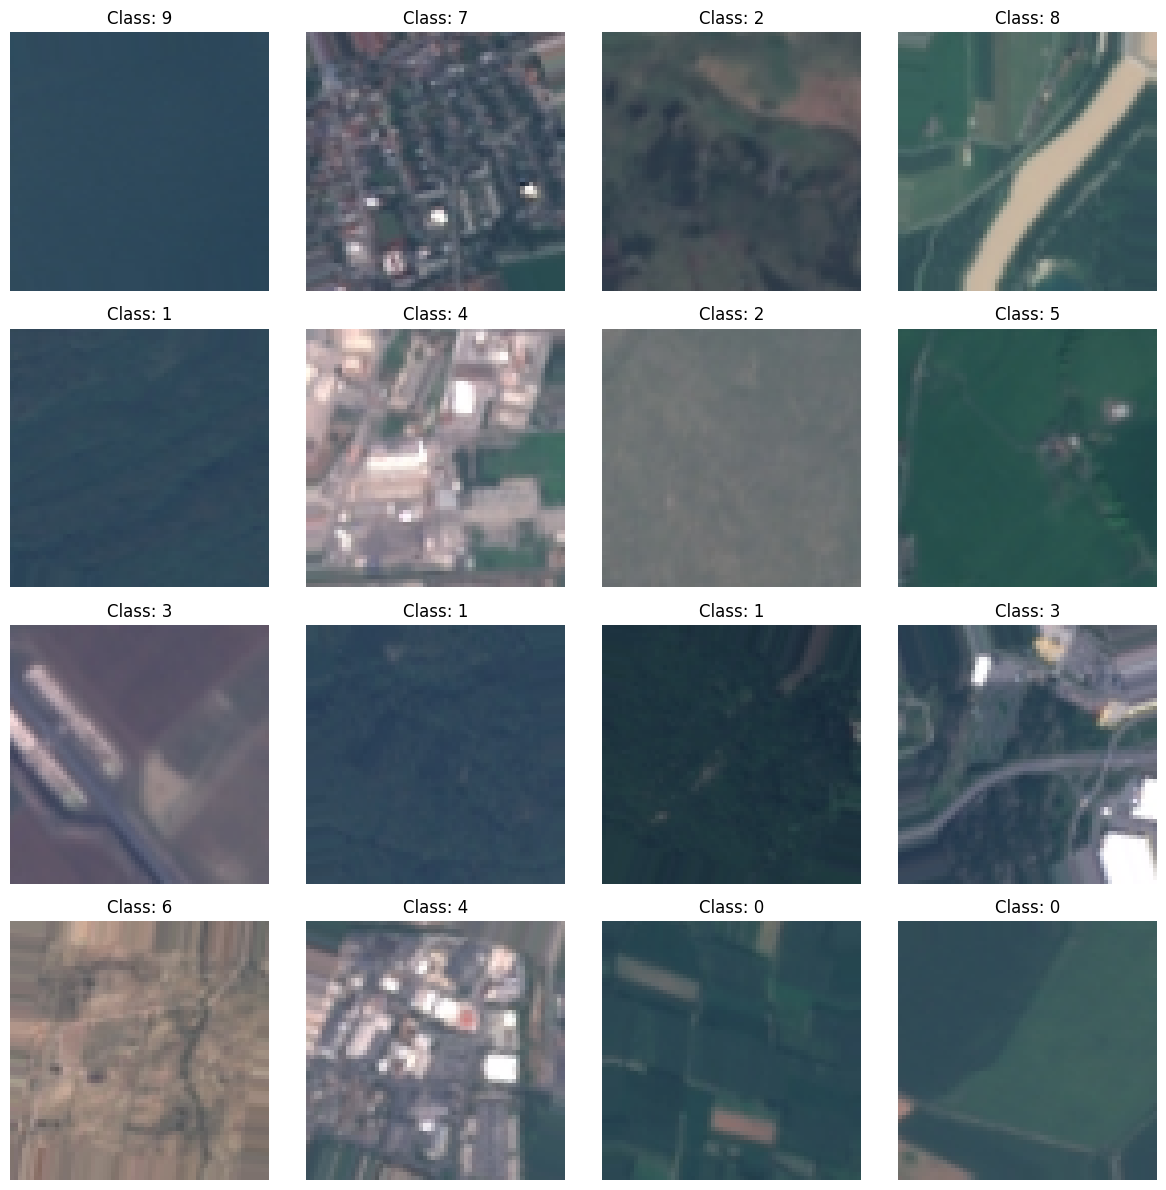

In [15]:
# Seprate the images and labels from training set
img, label = next(train_set)

plt.figure(figsize=(12, 12))
for i in range(16):  # Plotting 9 images
    plt.subplot(4, 4, i + 1)
    plt.imshow(img[i])
    plt.title(f'Class: {label[i].argmax()}')  # Assuming labels are one-hot encoded
    plt.axis('off')
plt.tight_layout()
plt.show()

## **STATISTICAL ANALYSIS ON IMAGES**

## 1. Mean and Standard Deviation Calculation of Pixel Intensities

In [47]:
# Load the image in RGB format
image_path = "/kaggle/input/eurosat/EuroSAT_RGB/Highway/Highway_1021.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Calculate mean and standard deviation for each color channel
means = image_rgb.mean(axis=(0, 1))
std_devs = image_rgb.std(axis=(0, 1))

# Display the results
print(f"Mean Intensities (R, G, B): {means}")
print(f"Standard Deviations (R, G, B): {std_devs}")

Mean Intensities (R, G, B): [103.0625     107.96240234 112.13037109]
Standard Deviations (R, G, B): [45.15743402 28.24958608 24.37467138]


* Mean values show the average brightness for each color channel.
* Standard deviations indicate how much brightness varies, helping to understand image contrast.

## 2. Edge Detection using Canny Filter

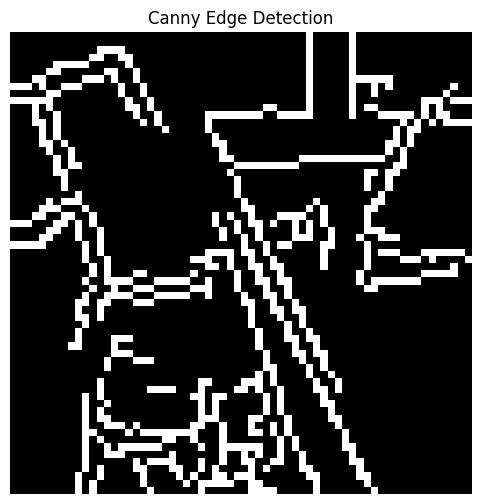

In [48]:
# Convert the image to grayscale
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Apply Canny edge detection
edges = cv2.Canny(image_gray, threshold1=100, threshold2=200)

# Display the edges
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

### **CONVOLUTIONAL NEURAL NETWORK (DCNN)**

In [12]:
# Create Sequential model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10,activation='softmax'))

## **EXTRACTED FEATURES AFTER CONVOLUTION & MAXPOOLING**

In [42]:
image = cv2.imread("/kaggle/input/eurosat/EuroSAT_RGB/Industrial/Industrial_1008.jpg")
image = cv2.resize(image, (64, 64))
image = image/255.0
image = image.reshape(1, image.shape[0], image.shape[1], 3)

In [43]:
conv_layer = tf.keras.layers.Conv2D(filters=1, kernel_size=(3,3), strides=(1,1), padding='valid')
pool_layer = tf.keras.layers.MaxPool2D(pool_size = (2,2), strides=(2,2))
conv_output = conv_layer(image)
pooled_output = pool_layer(conv_output)

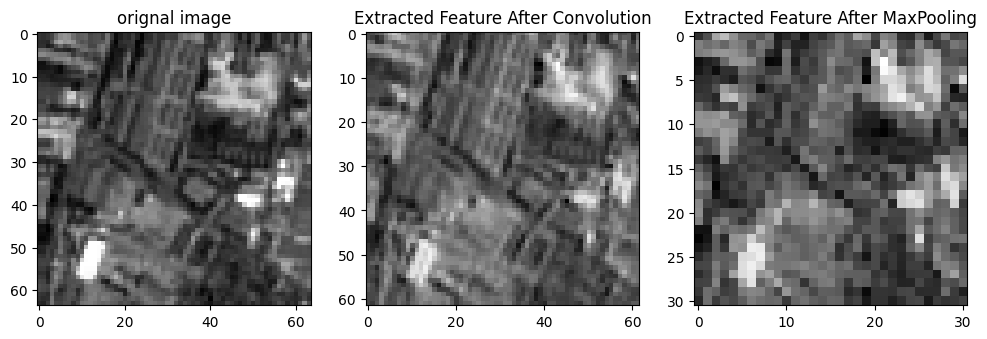

In [44]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].imshow(image[0,:,:,0], cmap='gray')
axs[0].set_title('orignal image')
axs[1].imshow(conv_output[0,:,:,0], cmap='gray')
axs[1].set_title('Extracted Feature After Convolution')
axs[2].imshow(pooled_output[0,:,:,0], cmap='gray')
axs[2].set_title('Extracted Feature After MaxPooling')
plt.show()

In [18]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.7/993.7 kB 27.1 MB/s eta 0:00:0000:01


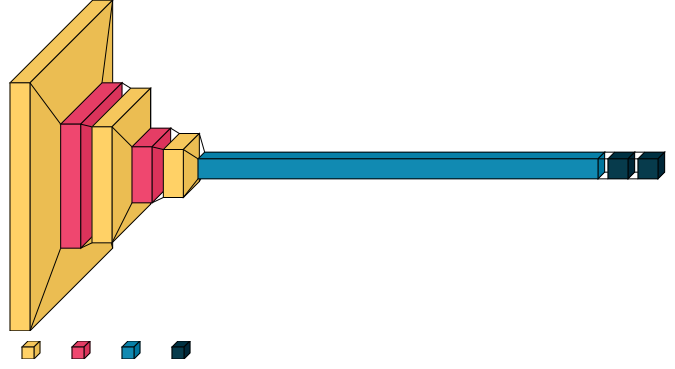

In [21]:
import visualkeras
visualkeras.layered_view(model, legend=True, draw_volume=True)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

### **COMPILE AND TRAIN MODEL**

In [23]:
# Compile the model with Adam optimizer
model.compile(optimizer="adam",
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [26]:
# Use ModelCheckPoint and Early stopping to avoid overfitting problem
early_stop = EarlyStopping(monitor='val_loss',
                                patience=10,
                                verbose=1)

modelCheckpoint = ModelCheckpoint(filepath='landslide_model.keras',
                                       monitor='val_loss',
                                       verbose=True,
                                       save_best_only=True)

# fit model for training
history = model.fit(train_set,
                    epochs=40,
                    validation_data=val_set,
                    class_weight=class_weight_dict,
                    callbacks=[early_stop,modelCheckpoint])

Epoch 1/40
669/675 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6684 - loss: 0.9320
Epoch 1: val_loss improved from inf to 0.99475, saving model to landslide_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.6686 - loss: 0.9315 - val_accuracy: 0.6415 - val_loss: 0.9948
Epoch 2/40
668/675 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7327 - loss: 0.7519
Epoch 2: val_loss improved from 0.99475 to 0.59837, saving model to landslide_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.7328 - loss: 0.7516 - val_accuracy: 0.7833 - val_loss: 0.5984
Epoch 3/40
668/675 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7462 - loss: 0.7034
Epoch 3: val_loss did not improve from 0.59837
675/675 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.7463 - loss: 0.7031 - val_accuracy: 0.7163 - val_loss: 0.7795
Epoch 4/40
668/675 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7774 - loss: 0.6243
Epoch 4: val_loss did not improve from 0.59837
675/675 ━━━━━━━━━━━━━━━━━

### **PLOT DCNN MODEL TRAIN ACCURACY & LOSS AS WELL AS VALIDATION ACCURACY LOSS**

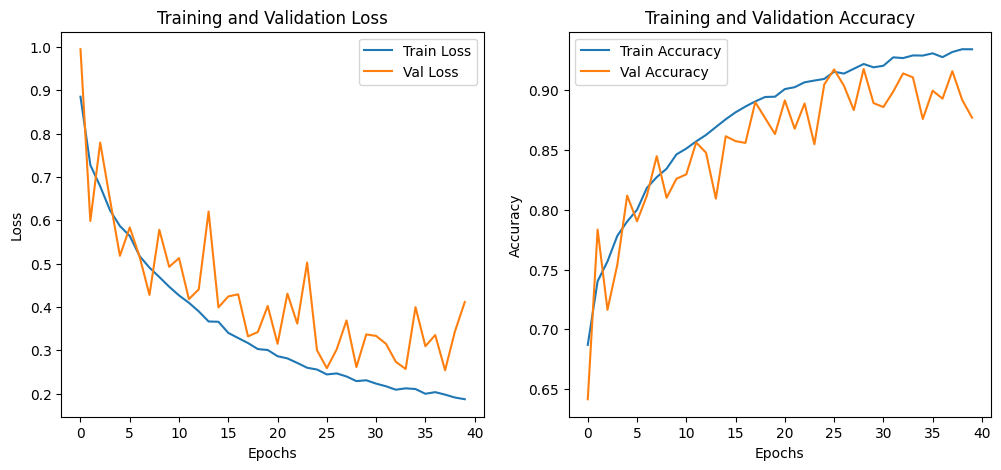

In [50]:
plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Plotting Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.show()


In [28]:
train_loss, train_accuracy = model.evaluate(train_set)
test_loss, test_accuracy = model.evaluate(test_set)
print(f"Train Loss:{train_loss:.4f}")
print(f"Train Accuracy:{train_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

675/675 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.9290 - loss: 0.1998
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8904 - loss: 0.3504
Train Loss:0.2031
Train Accuracy:0.9290
Test Loss: 0.3924
Test Accuracy: 0.8826


* CNN model training accuray is 92.90% and testing accuracy is 88.26%.

### **PREDICTION ON TEST DATA**

In [29]:
# Predict labels for the test set
ypred = model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


In [30]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", confusion_matrix)

Confusion Matrix:
 [[5 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0]
 [0 0 3 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 5 0 0]
 [0 0 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 5]]


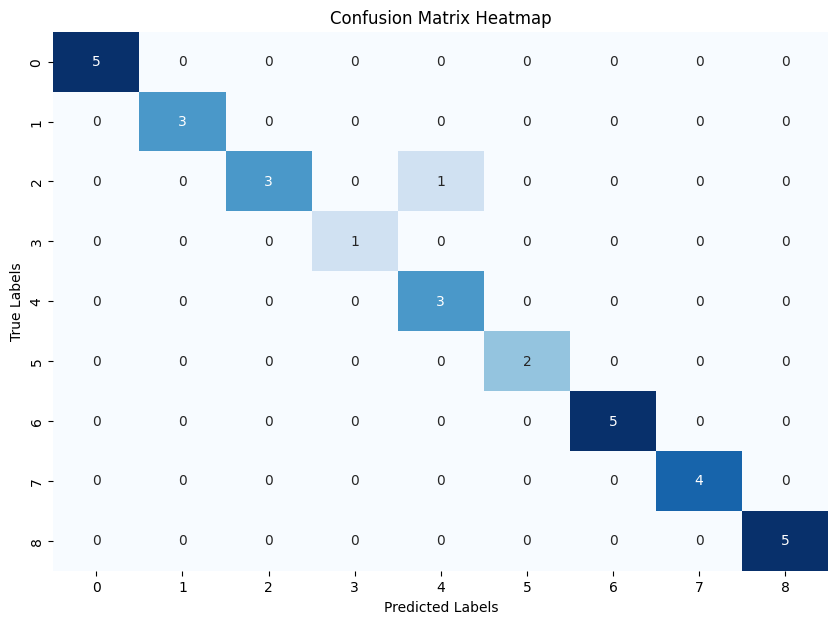

In [32]:
# Plotting the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [33]:
# F1 Score
f1score = f1_score(y_test_labels, y_pred_labels,average='weighted')
print("F1 Score:", f1score*100)

F1 Score: 96.875


### **MAKE PREDICTION ON DCNN MODEL**

In [36]:
cnn_y_hat = model.predict(test_set)
cnn_y_hat

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


array([[1.15745067e-17, 6.52459633e-16, 3.86486887e-09, ...,
        9.99999762e-01, 1.01722597e-09, 1.49894537e-23],
       [1.26339885e-11, 1.18649502e-12, 1.73747850e-07, ...,
        9.99932051e-01, 1.44783527e-07, 3.34037443e-21],
       [5.53457448e-06, 4.64301337e-07, 9.33272531e-06, ...,
        6.21795516e-06, 4.31812368e-02, 7.12170413e-06],
       ...,
       [6.88023067e-18, 6.67269956e-32, 7.91560963e-14, ...,
        1.73665370e-11, 1.97365648e-11, 4.03205635e-21],
       [6.93811671e-05, 9.76759154e-08, 2.14974760e-04, ...,
        1.09264611e-11, 9.99697030e-01, 6.75814192e-07],
       [5.06164069e-19, 6.47117414e-18, 1.43924355e-13, ...,
        1.00000000e+00, 7.34810867e-13, 6.71120911e-28]], dtype=float32)

## TEST RANDOM IMAGES USING GRADIO

In [37]:
# Load your model
model = load_model('landslide_model.keras')

# Define the class names
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 
               'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


# Preprocess the image
def preprocess_image(image):
    image = cv2.resize(image, (64,64))
    image = img_to_array(image)
    image = image / 255.0  # Scale pixel values
    image = tf.expand_dims(image, axis=0)  # Add batch dimension
    return image

# Create function for prediction
def predict(image):
    image_np = np.array(image) # Convert PIL Image to numpy array
    processed_image = preprocess_image(image_np) # Preprocess the CLAHE image
    prediction = model.predict(processed_image)  # Make prediction
    class_idx = tf.argmax(prediction, axis=1).numpy()[0]
    confidence = tf.reduce_max(prediction).numpy()
    return clahe_image, class_names[class_idx], f"{confidence:.2f}"

In [7]:
# Create gradio interface
iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload an Image'),
    outputs=[
        gr.Label(label='Predicted Class'),
        gr.Textbox(label='Confidence')],
    title='Landslide Image Classification',
    description='Upload a landslide image to classify it as one of the following: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, or SeaLake.')

# Launch the interface
iface.launch(share=True)

Running on local URL:  http://127.0.0.1:7861



Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2024/08/03 14:36:44 [W] [service.go:132] login to server failed: EOF


### Visualize Feature Maps

In [42]:
from keras.models import load_model, Model
from keras.preprocessing.image import load_img, img_to_array
from numpy import expand_dims
from matplotlib import pyplot

In [43]:
# Load your DCNN model
model = load_model("landslide_model.keras")

# Redefine the model to output layers for feature extraction
layer_indices = [0, 1, 2, 3] 
outputs = [model.layers[i].output for i in layer_indices]
feature_extraction_model = Model(inputs=model.inputs, outputs=outputs)

# Load and preprocess the image
img = load_img("/kaggle/working/output/test/Forest/Forest_2394.jpg", target_size=(64, 64))  # Adjust target_size if needed
img = img_to_array(img)
img = expand_dims(img, axis=0)
img = img / 255.0  # Normalize image if required

# Get feature maps
feature_maps = feature_extraction_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


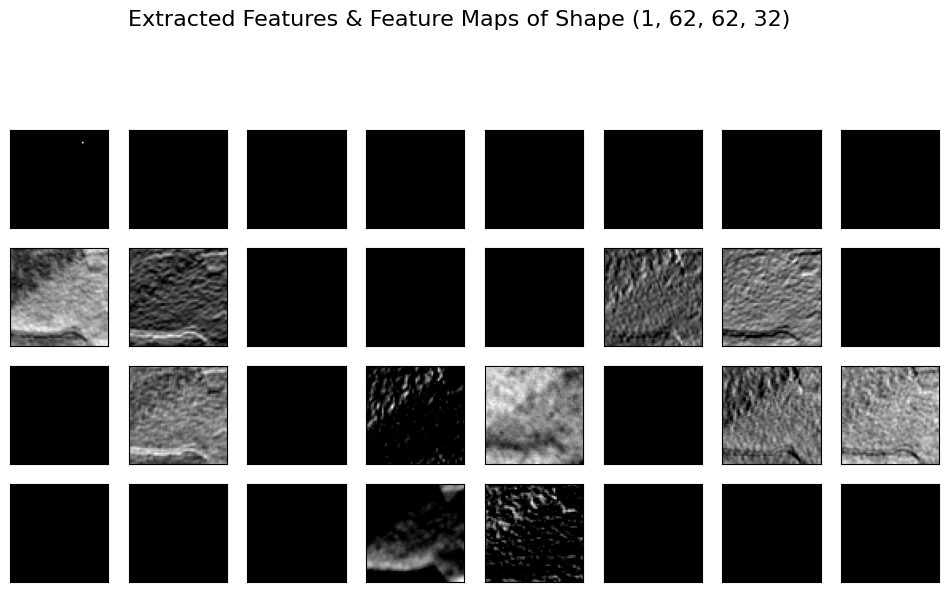

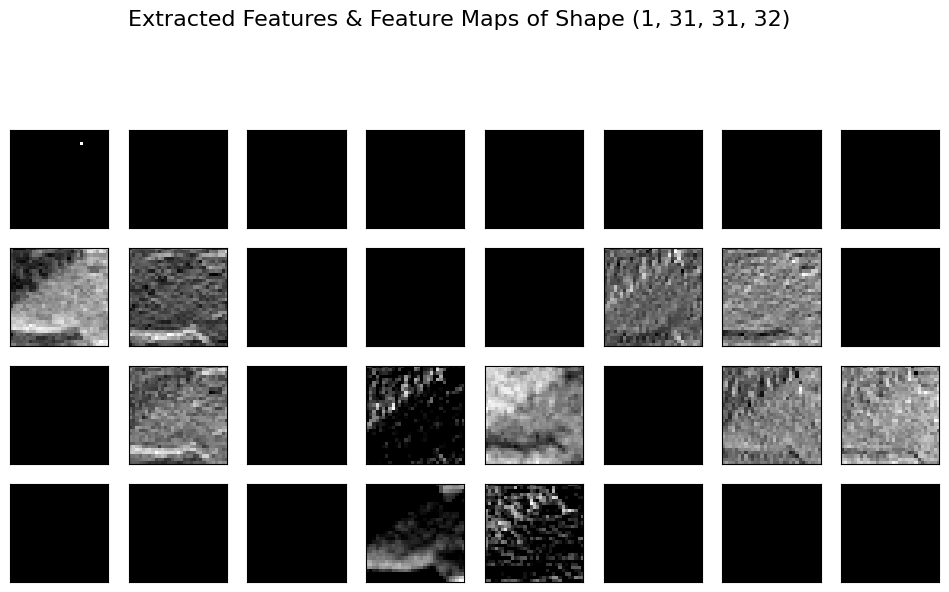

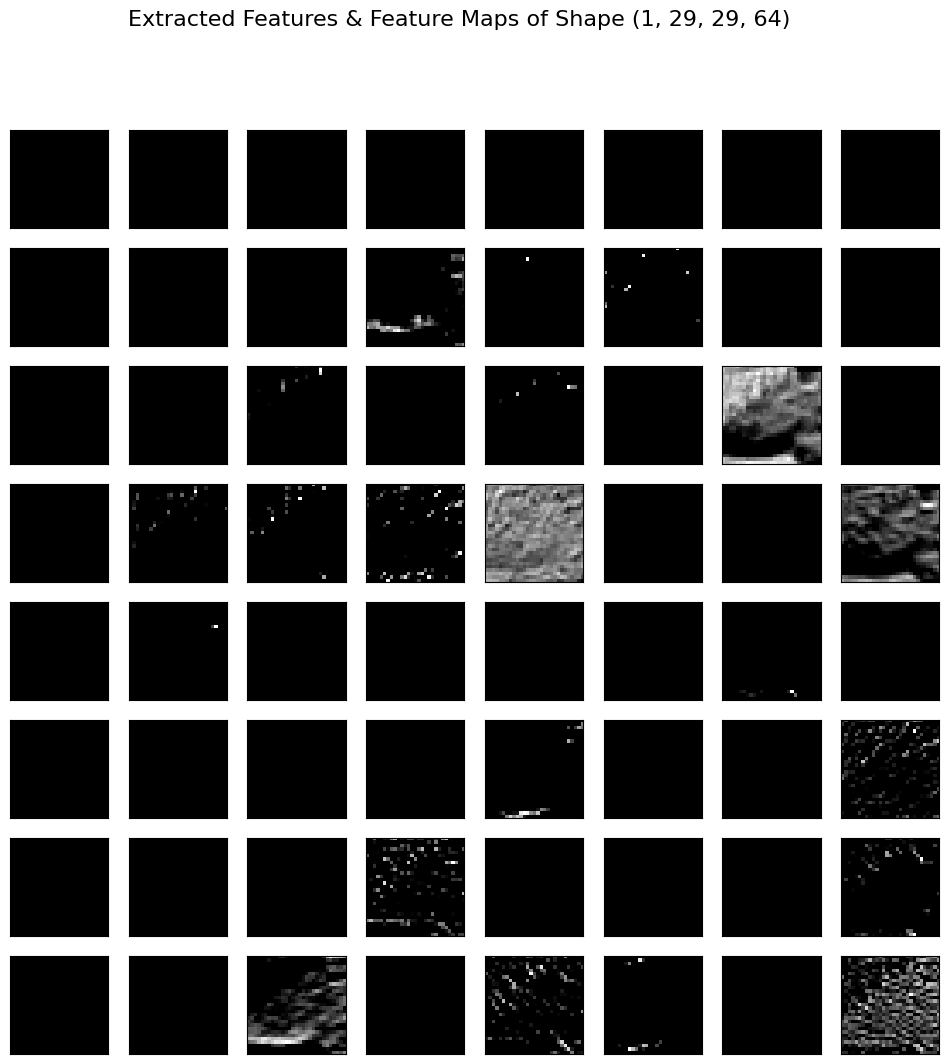

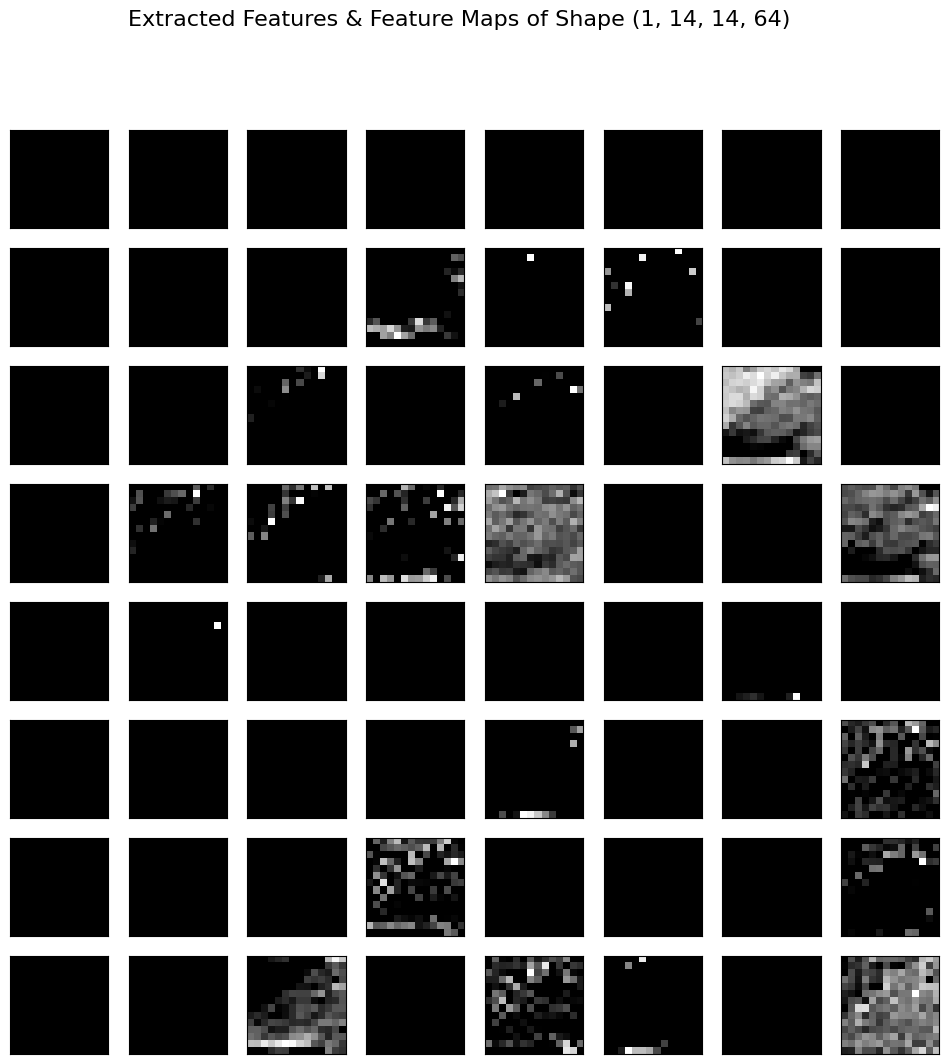

In [46]:
grid_size = 8

for fmap in feature_maps:
    depth = fmap.shape[-1]
    num_plots = min(grid_size * grid_size, depth)
    
    plt.figure(figsize=(12, 12))
    
    for i in range(num_plots):
        ax = plt.subplot(grid_size, grid_size, i + 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(fmap[0, :, :, i], cmap='gray')
        
    plt.suptitle(f'Extracted Features & Feature Maps of Shape {fmap.shape}', fontsize=16)
    plt.show()